In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel('D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\EDA\\data sheets\\EDA_news_popularity.xlsx')

# Quick look
print(df.shape)
df.head()


(39644, 61)


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731,12,219,0.663594,1.0,0.815385,4,2,1,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731,9,255,0.604743,1.0,0.791946,3,1,1,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731,9,211,0.575130,1.0,0.663866,3,1,1,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731,9,531,0.503788,1.0,0.665635,9,0,1,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731,13,1072,0.415646,1.0,0.540890,19,19,20,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


count     39644.000000
mean       3395.380184
std       11626.950749
min           1.000000
25%         946.000000
50%        1400.000000
75%        2800.000000
max      843300.000000
Name: shares, dtype: float64
Skewness: 33.96388487571415
Kurtosis: 1832.6726571600288


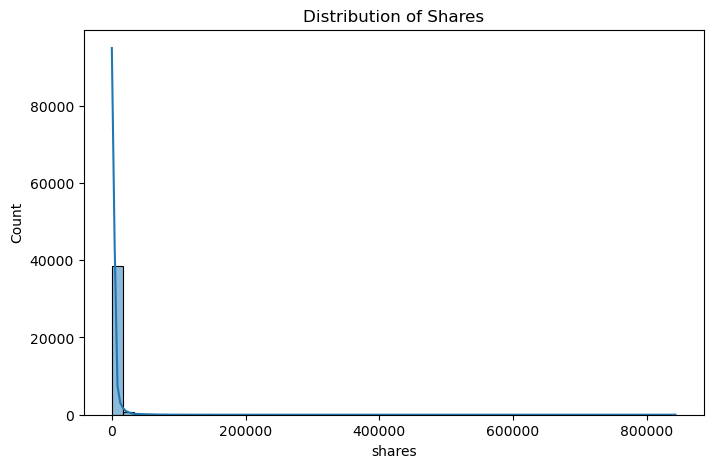

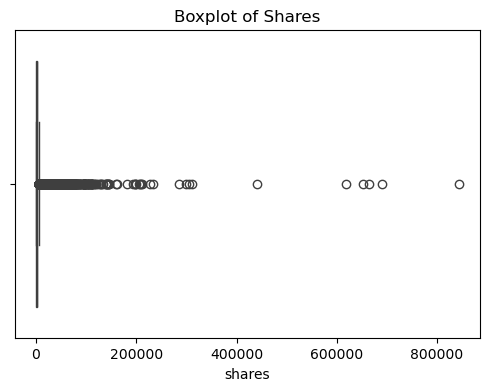

In [2]:
#Basic Univariate Analysis (Shares)
# Summary statistics
print(df['shares'].describe())
print("Skewness:", df['shares'].skew())
print("Kurtosis:", df['shares'].kurt())

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['shares'], bins=50, kde=True)
plt.title("Distribution of Shares")
plt.show()

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['shares'])
plt.title("Boxplot of Shares")
plt.show()


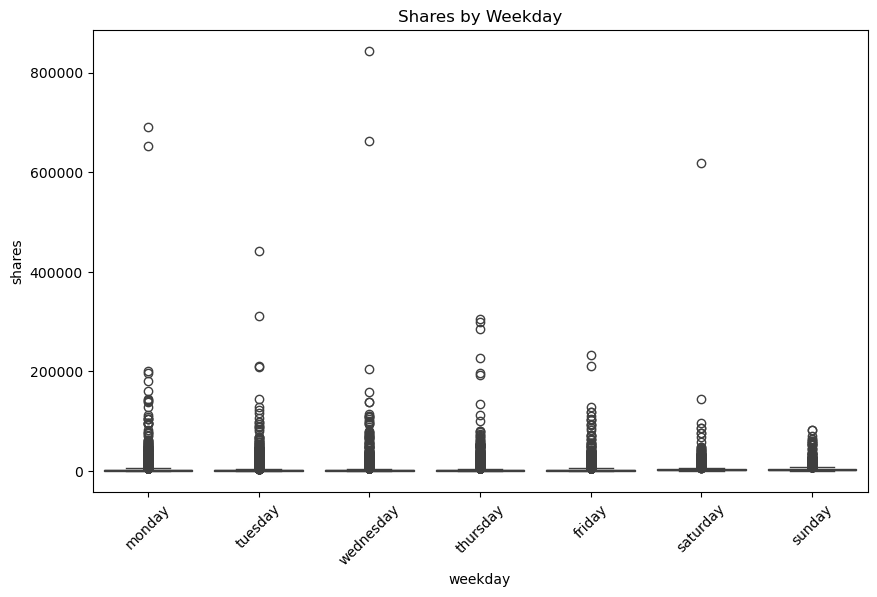

In [4]:
#Segmented by Weekday (Monday–Sunday)
# Create a column for weekday
weekdays = ['monday','tuesday','wednesday','thursday','friday','saturday','sunday']
for i, day in enumerate(weekdays):
    df[day] = df[f' weekday_is_{day}']

# Assign weekday label
df['weekday'] = df[weekdays].idxmax(axis=1)

# Boxplot by weekday
plt.figure(figsize=(10,6))
sns.boxplot(x='weekday', y='shares', data=df)
plt.title("Shares by Weekday")
plt.xticks(rotation=45)
plt.show()


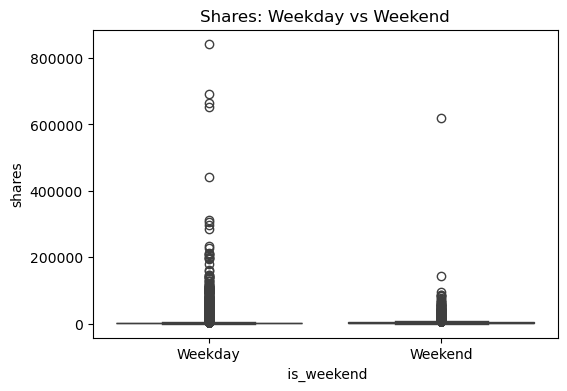

               count         mean           std   min     25%     50%     75%  \
 is_weekend                                                                     
0            34454.0  3318.855140  11748.276260   1.0   913.0  1400.0  2600.0   
1             5190.0  3903.394412  10774.274007  43.0  1300.0  1900.0  3600.0   

                  max  
 is_weekend            
0            843300.0  
1            617900.0  


In [5]:
#Segmented by Weekend vs Weekday
plt.figure(figsize=(6,4))
sns.boxplot(x=' is_weekend', y='shares', data=df)
plt.xticks([0,1], ["Weekday", "Weekend"])
plt.title("Shares: Weekday vs Weekend")
plt.show()

# Compare stats
print(df.groupby(' is_weekend')['shares'].describe())


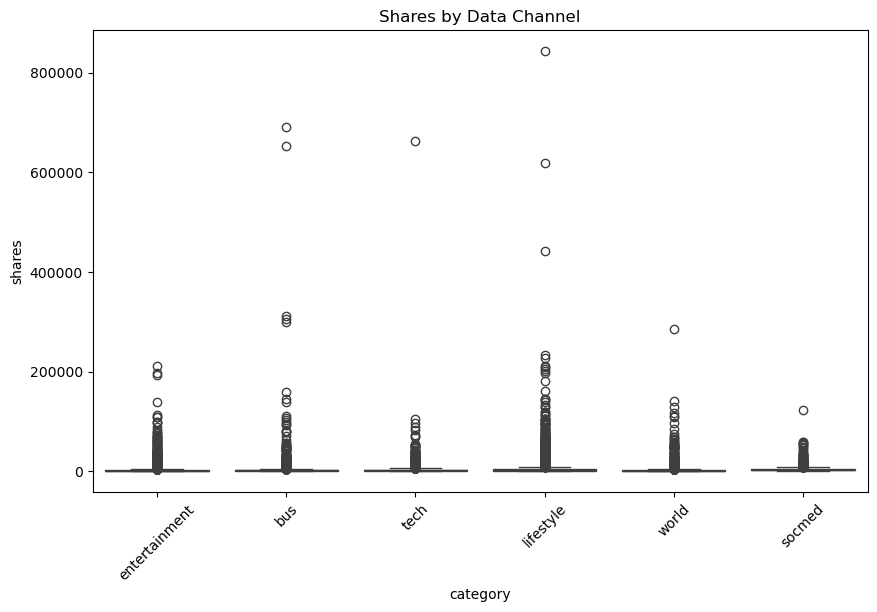

                count         mean           std   min      25%     50%  \
category                                                                  
bus            6258.0  3063.018536  15046.387626   1.0   952.25  1400.0   
entertainment  7057.0  2970.487034   7858.133920  47.0   833.00  1200.0   
lifestyle      8233.0  5368.221790  17357.579552   4.0  1100.00  1800.0   
socmed         2323.0  3629.383125   5524.167095   5.0  1400.00  2100.0   
tech           7346.0  3072.283283   9024.343803  36.0  1100.00  1700.0   
world          8427.0  2287.734069   6089.669476  35.0   827.00  1100.0   

                  75%       max  
category                         
bus            2500.0  690400.0  
entertainment  2100.0  210300.0  
lifestyle      4300.0  843300.0  
socmed         3800.0  122800.0  
tech           3000.0  663600.0  
world          1900.0  284700.0  


In [6]:
#Segmented by Data Channel (Article Category)
channels = [' data_channel_is_lifestyle',' data_channel_is_entertainment',
            ' data_channel_is_bus',' data_channel_is_socmed',
            ' data_channel_is_tech',' data_channel_is_world']

# Assign main category
df['category'] = df[channels].idxmax(axis=1).str.replace(" data_channel_is_","")

# Boxplot by category
plt.figure(figsize=(10,6))
sns.boxplot(x='category', y='shares', data=df)
plt.title("Shares by Data Channel")
plt.xticks(rotation=45)
plt.show()

# Summary stats
print(df.groupby('category')['shares'].describe())


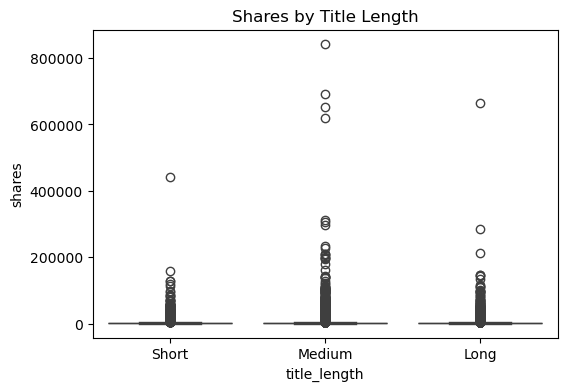

In [8]:
#Segmented by Title Length
# Title length segmentation
df['title_length'] = pd.cut(df[' n_tokens_title'],
                            bins=[0,8,12,100],
                            labels=['Short','Medium','Long'])

plt.figure(figsize=(6,4))
sns.boxplot(x='title_length', y='shares', data=df)
plt.title("Shares by Title Length")
plt.show()


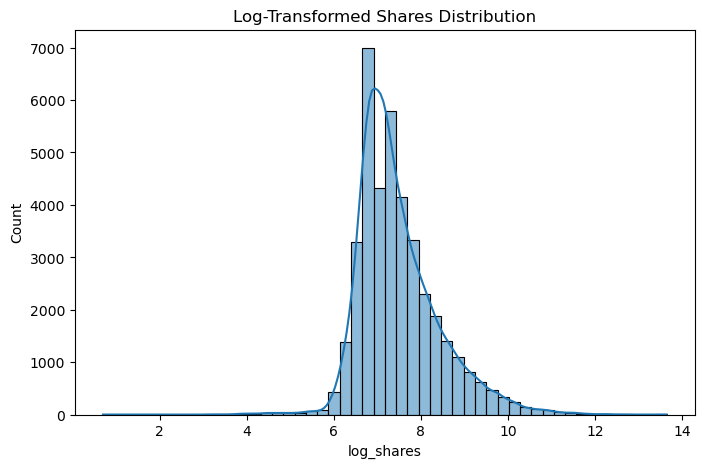

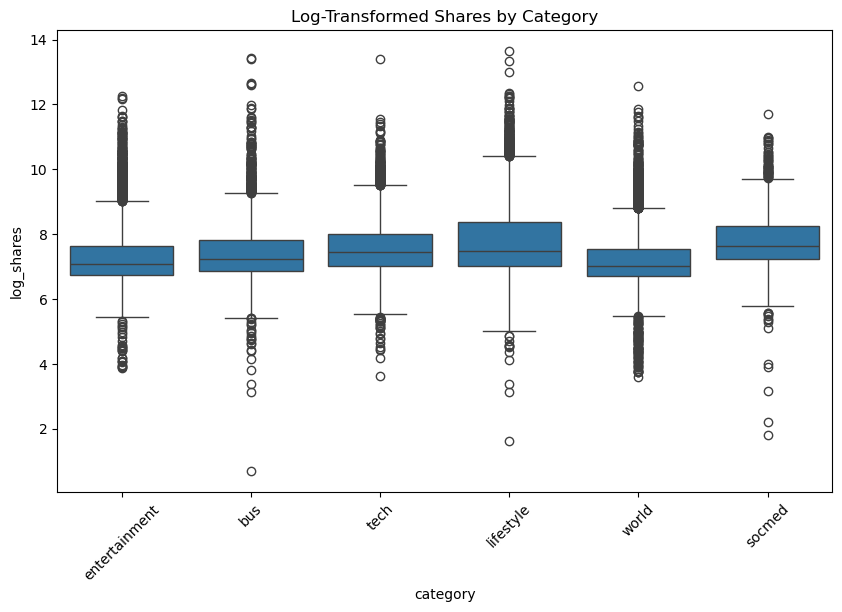

In [9]:
#Log Transformation
df['log_shares'] = np.log1p(df['shares'])

plt.figure(figsize=(8,5))
sns.histplot(df['log_shares'], bins=50, kde=True)
plt.title("Log-Transformed Shares Distribution")
plt.show()

# Segmented log boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='category', y='log_shares', data=df)
plt.title("Log-Transformed Shares by Category")
plt.xticks(rotation=45)
plt.show()
